# C. 카테고리·상품별 매출 시계열 & 예측

월별·카테고리별 매출/주문 건수 시계열을 만들고, **Prophet 또는 ARIMA**로 단기 예측합니다.

**사용 데이터**: `data/` (00 실행 후).

## 1. 데이터 로드 및 월별 집계

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path.cwd() / "data"
for _ in [Path.cwd() / "data", Path.cwd().parent / "예측 대시보드 용 프로젝트" / "data"]:
    if (_ / "orders_delivered.csv").exists():
        DATA_DIR = _
        break
if not (DATA_DIR / "orders_delivered.csv").exists():
    import kagglehub
    _path = Path(kagglehub.dataset_download("olistbr/brazilian-ecommerce"))
    orders = pd.read_csv(_path / "olist_orders_dataset.csv")
    orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"], errors="coerce")
    orders = orders[orders["order_status"] == "delivered"].copy()
    order_items = pd.read_csv(_path / "olist_order_items_dataset.csv")
    products = pd.read_csv(_path / "olist_products_dataset.csv")
    products["product_category_name"] = products["product_category_name"].fillna("unknown")
    print("(data/ 없음 → kagglehub에서 로드)")
else:
    orders = pd.read_csv(DATA_DIR / "orders_delivered.csv")
    order_items = pd.read_csv(DATA_DIR / "order_items.csv")
    products = pd.read_csv(DATA_DIR / "products.csv")

orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"], errors="coerce")
orders["month"] = orders["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()
orders["order_week_start"] = orders["order_purchase_timestamp"].dt.to_period("W-MON").dt.start_time

ord = order_items.merge(products[["product_id", "product_category_name"]], on="product_id", how="left")
ord["product_category_name"] = ord["product_category_name"].fillna("unknown")
ord = ord.merge(orders[["order_id", "month", "order_week_start"]], on="order_id")

# 월별 전체 매출·주문수
monthly = ord.groupby("month").agg(revenue=("price", "sum"), order_count=("order_id", "nunique")).reset_index()
# 주별 전체 매출·주문수 (대시보드용)
weekly = ord.groupby("order_week_start").agg(revenue=("price", "sum"), order_count=("order_id", "nunique")).reset_index()
print("월별:")
print(monthly.head(10))
print("\n주별:")
print(weekly.head(10))

       month    revenue  order_count
0 2016-09-01    134.970            1
1 2016-10-01  40325.110          265
2 2016-12-01     10.900            1
3 2017-01-01 111798.360          750
4 2017-02-01 234223.400         1653
5 2017-03-01 359198.850         2546
6 2017-04-01 340669.680         2303
7 2017-05-01 489338.250         3546
8 2017-06-01 421923.370         3135
9 2017-07-01 481604.520         3872


## 2. 시계열 시각화

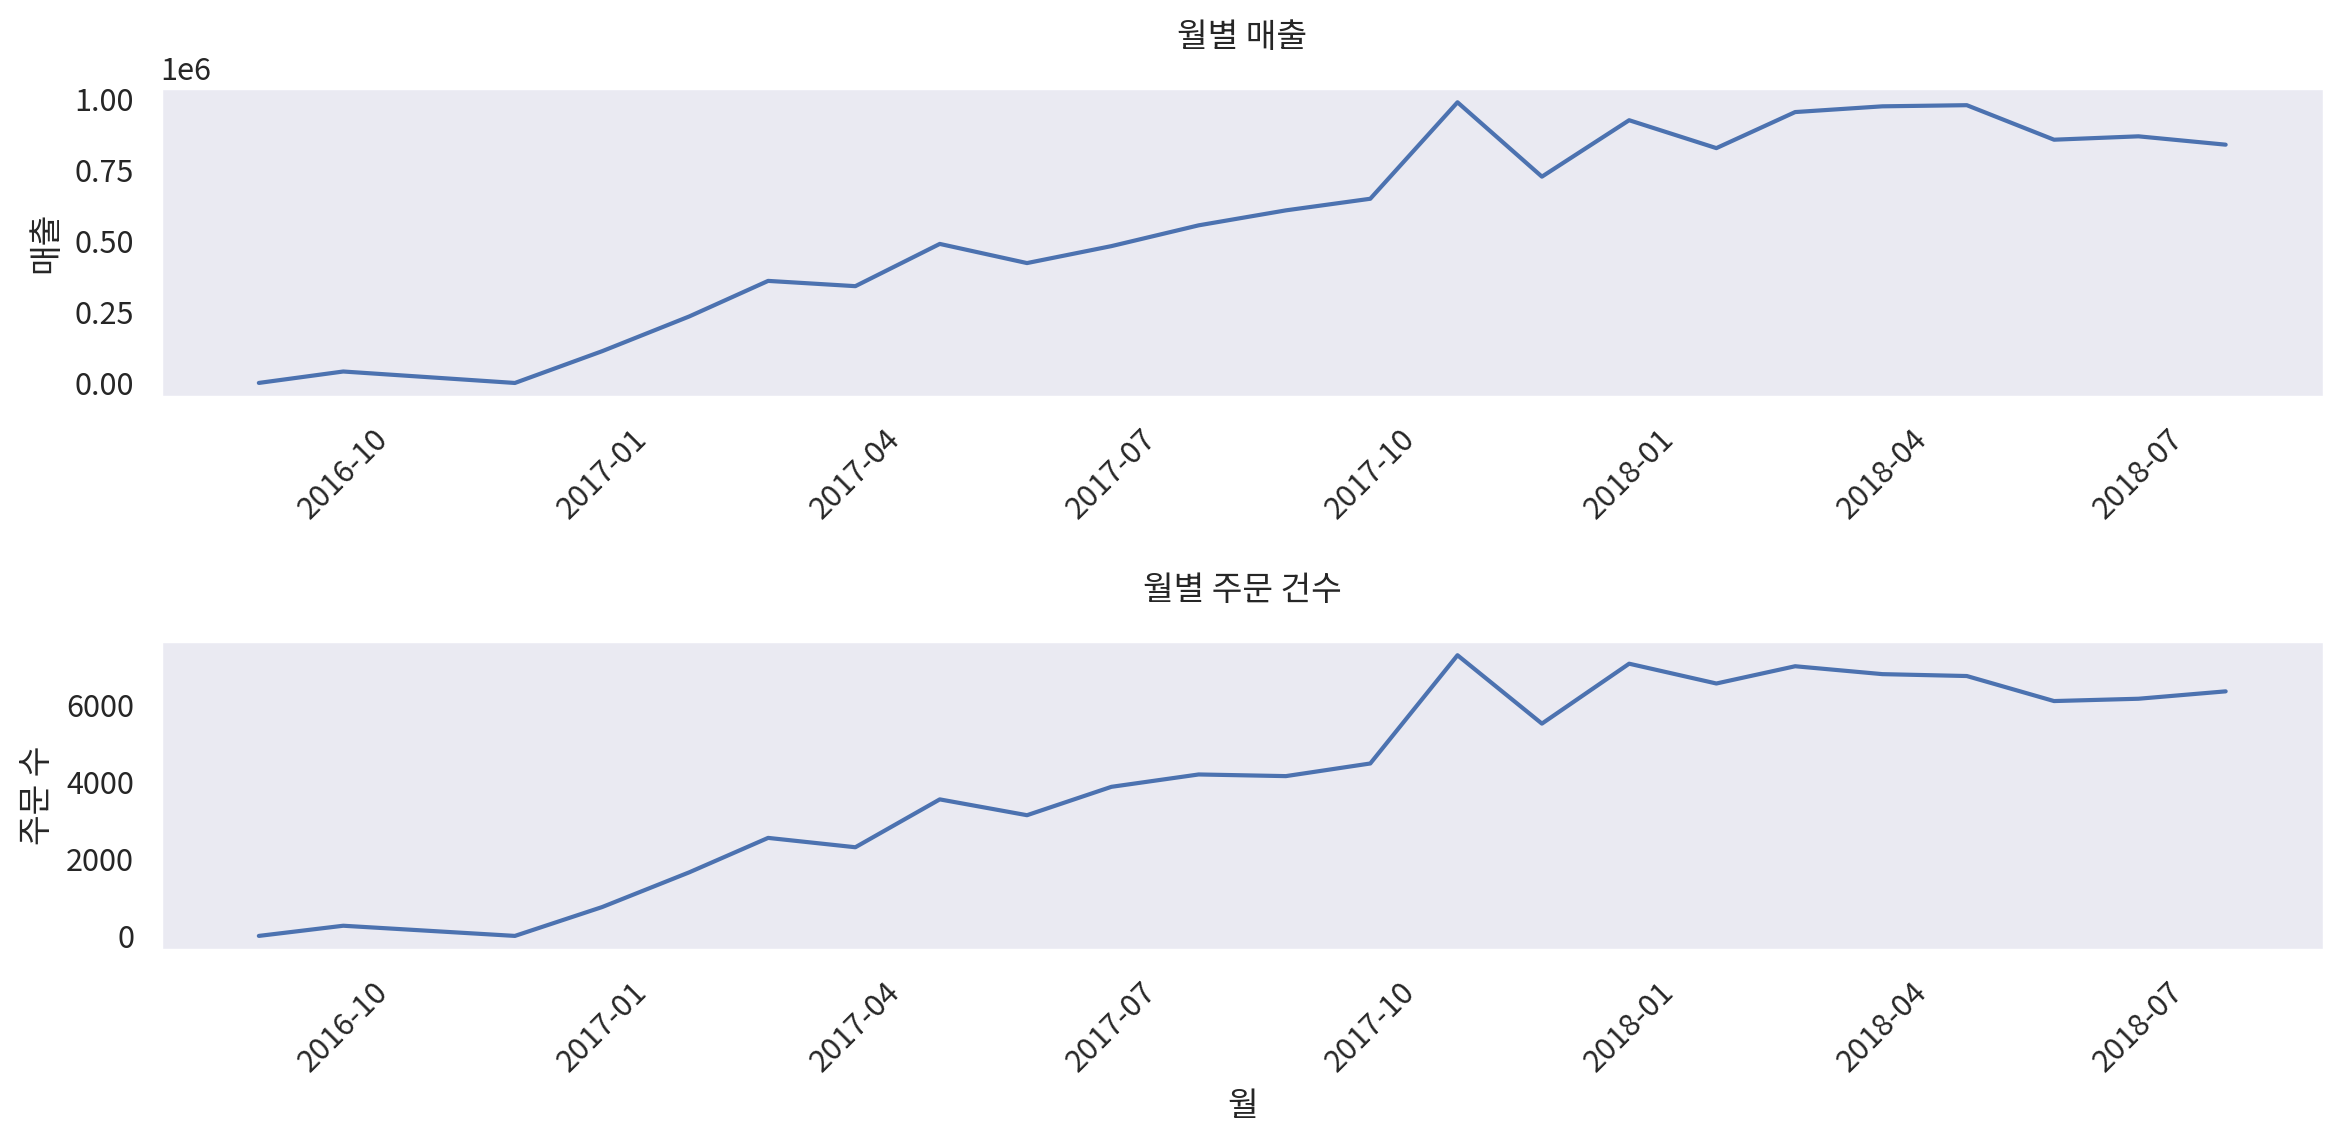

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(monthly["month"], monthly["revenue"])
axes[0].set_ylabel("매출")
axes[0].set_title("월별 매출")
axes[0].tick_params(axis="x", rotation=45)
axes[1].plot(monthly["month"], monthly["order_count"])
axes[1].set_ylabel("주문 수")
axes[1].set_xlabel("월")
axes[1].set_title("월별 주문 건수")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 3. Prophet 또는 단순 추세 예측

15:35:08 - cmdstanpy - INFO - Chain [1] start processing
15:35:09 - cmdstanpy - INFO - Chain [1] done processing


Prophet 6개월 예측 (매출 추세):
           ds        yhat  yhat_lower  yhat_upper
23 2018-08-31 2170972.905 2109006.913 2231965.565
24 2018-09-30 1826768.763 1764825.524 1887882.308
25 2018-10-31 -673388.054 -736511.387 -607376.870
26 2018-11-30 2022465.646 1959857.047 2082476.631
27 2018-12-31 2260151.255 2199427.036 2321775.436
28 2019-01-31  847846.645  788568.785  911026.115


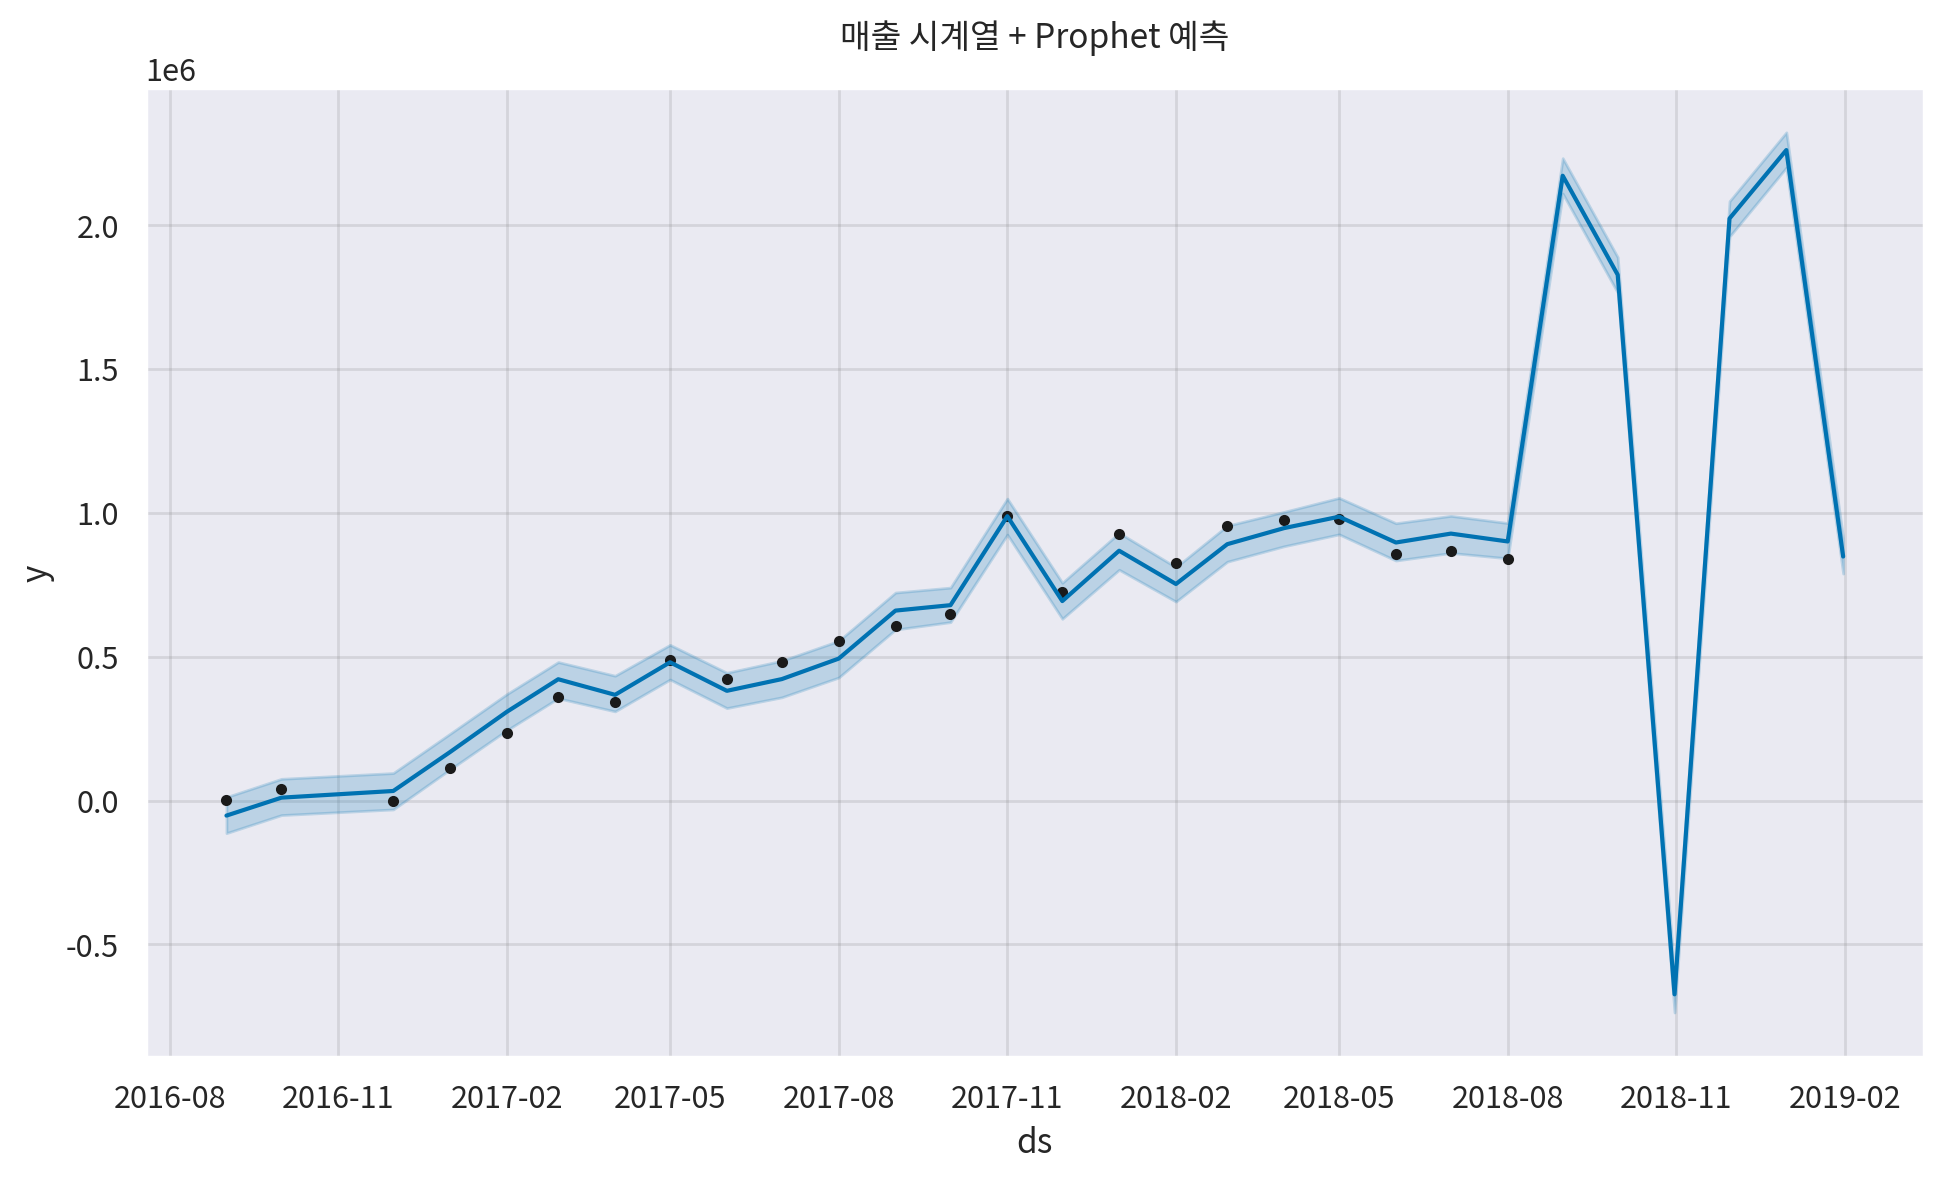

In [3]:
# Prophet 사용 가능 시 (pip install prophet)
try:
    from prophet import Prophet
    monthly_p = monthly.rename(columns={"month": "ds", "revenue": "y"})
    monthly_p["ds"] = pd.to_datetime(monthly_p["ds"])
    m = Prophet(yearly_seasonality=True)
    m.fit(monthly_p)
    future = m.make_future_dataframe(periods=6, freq="M")
    forecast = m.predict(future)
    print("Prophet 6개월 예측 (매출 추세):")
    print(forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(6))
    fig = m.plot(forecast)
    plt.title("매출 시계열 + Prophet 예측")
    plt.show()
except ImportError:
    # 단순 이동평균 기반 추세
    monthly["revenue_ma3"] = monthly["revenue"].rolling(3, center=True).mean()
    monthly["revenue_ma6"] = monthly["revenue"].rolling(6, center=True).mean()
    plt.figure(figsize=(12, 4))
    plt.plot(monthly["month"], monthly["revenue"], label="실제")
    plt.plot(monthly["month"], monthly["revenue_ma3"], label="3개월 이동평균")
    plt.plot(monthly["month"], monthly["revenue_ma6"], label="6개월 이동평균")
    plt.legend()
    plt.title("월별 매출 + 이동평균 (Prophet 미설치 시)")
    plt.tick_params(axis="x", rotation=45)
    plt.show()

## 4. 카테고리별 월별 매출 (상위 5개 카테고리)

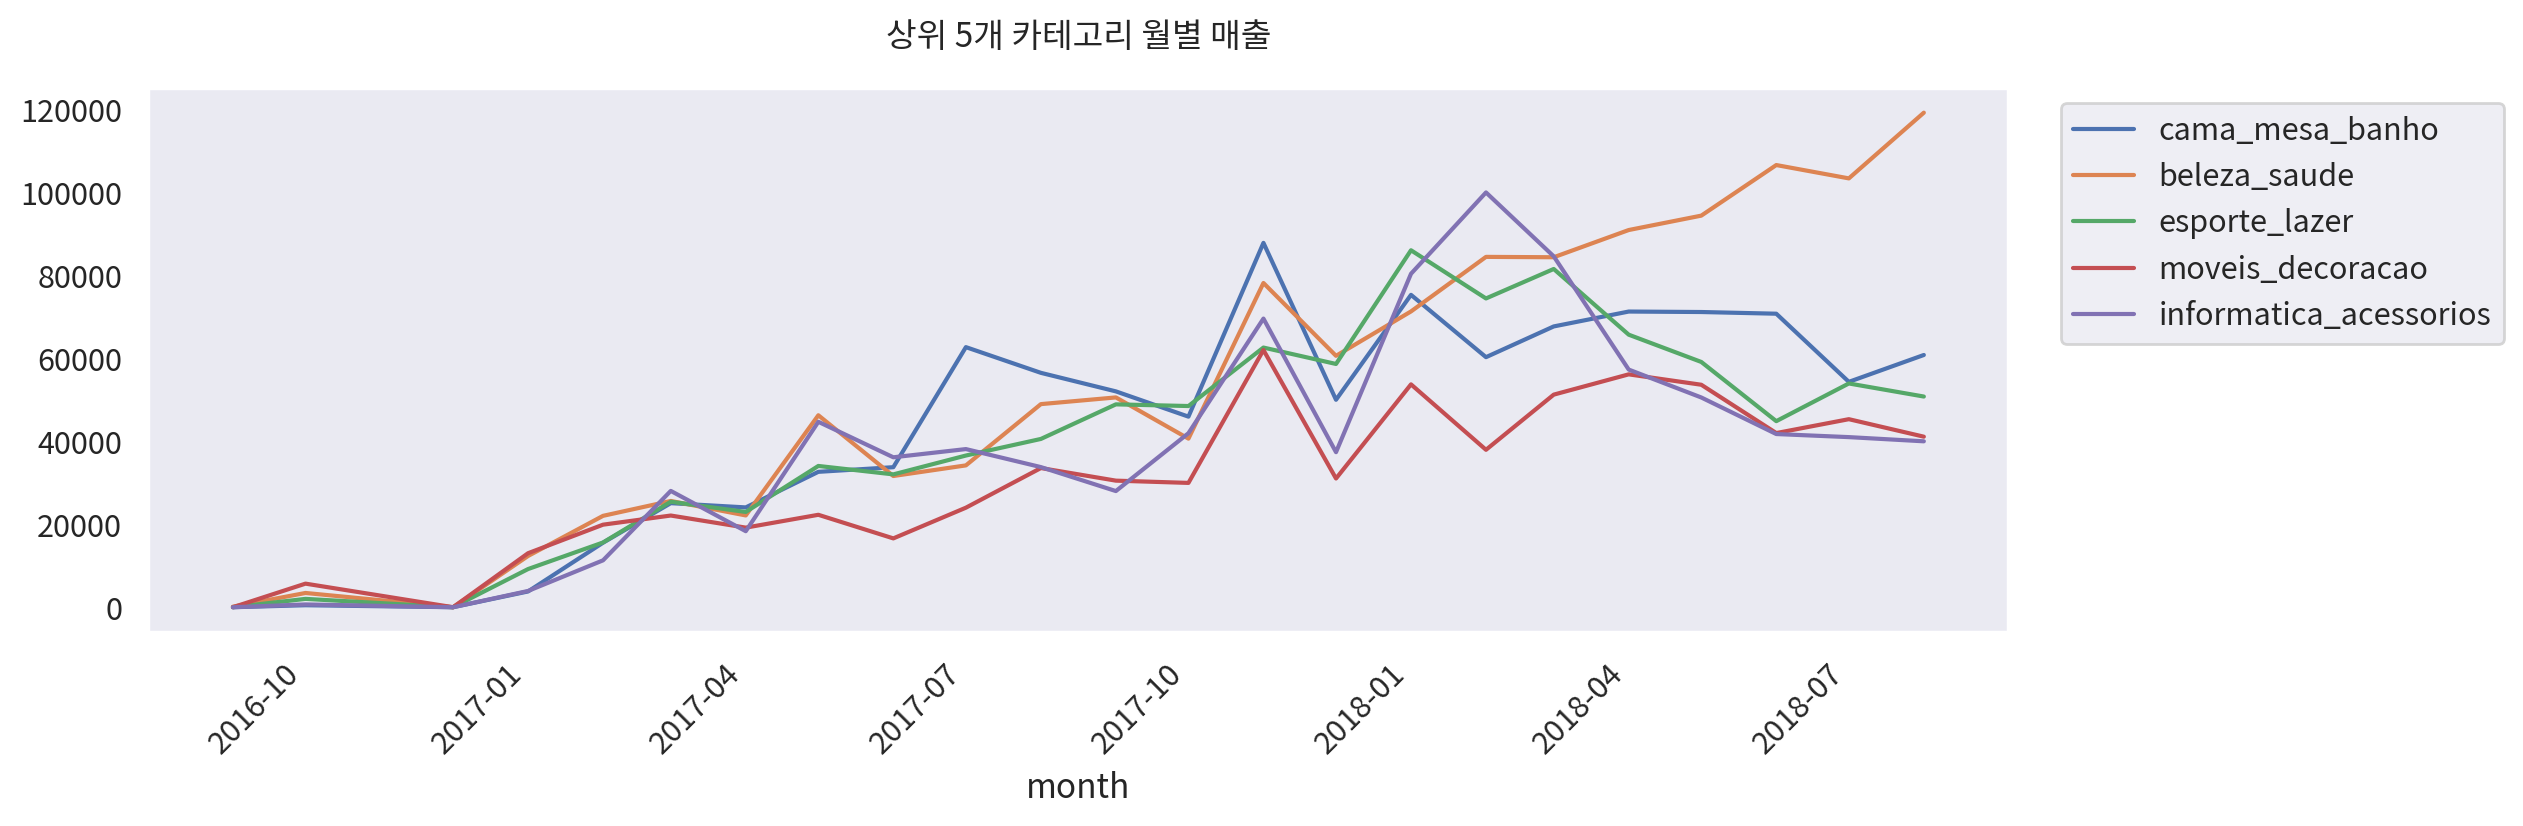

In [4]:
cat_monthly = ord.groupby(["month", "product_category_name"])["price"].sum().unstack(fill_value=0)
top_cats = ord["product_category_name"].value_counts().head(5).index.tolist()
cat_monthly_top = cat_monthly[[c for c in top_cats if c in cat_monthly.columns]]
cat_monthly_top.plot(figsize=(12, 4), title="상위 5개 카테고리 월별 매출")
plt.legend(bbox_to_anchor=(1.02, 1))
plt.tick_params(axis="x", rotation=45)
plt.show()

### 주별 카테고리 매출 (대시보드용)

**order_week_start** 기준 주별·카테고리별 매출 테이블입니다.

In [ ]:
cat_weekly = ord.groupby(["order_week_start", "product_category_name"])["price"].sum().reset_index()
cat_weekly = cat_weekly.rename(columns={"price": "revenue"})
print("주별·카테고리별 매출 (행 수):", len(cat_weekly))
print(cat_weekly.head(10))